In [1]:
import csv
from xmlrpc.client import boolean

import pandas as pd
import torch

df_raw = pd.read_csv("train.csv")


In [2]:
df_raw.head()

,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X11,X12,X13,X14,X15,X16,X17,X18,X19,Y
0,256039,3600.0,a,7.37,b,a,b,62004.0,a,Feb-2009,...,3.50,6.0,0.0,5514.0,19.5,20.0,b,a,NaN,0
1,176486,12000.0,b,16.49,e,g,b,143000.0,a,Nov-2014,...,14.03,14.0,1.0,5808.0,75.4,36.0,a,a,1.0,0
2,392670,8500.0,b,11.49,a,b,b,27000.0,a,Jun-2010,...,0.89,12.0,0.0,449.0,2.0,22.0,b,a,NaN,1
3,46168,3725.0,a,10.99,a,l,a,14916.0,c,Nov-2015,...,32.42,14.0,0.0,6557.0,23.9,26.0,a,a,0.0,0
4,313821,28000.0,a,15.41,e,a,a,100000.0,b,Dec-2015,...,9.91,11.0,1.0,17499.0,53.2,29.0,b,a,0.0,1


In [29]:
from typing import *

In [30]:
import seaborn as sns

def plot_value(df, x: str, y: str | None = None):
    if y:
        sns.scatterplot(data=df,x=x, y=y)
    else:
        sns.histplot(data=df,x=x)


Count Y distribution
Y
0    254686
1     62138
Name: count, dtype: int64


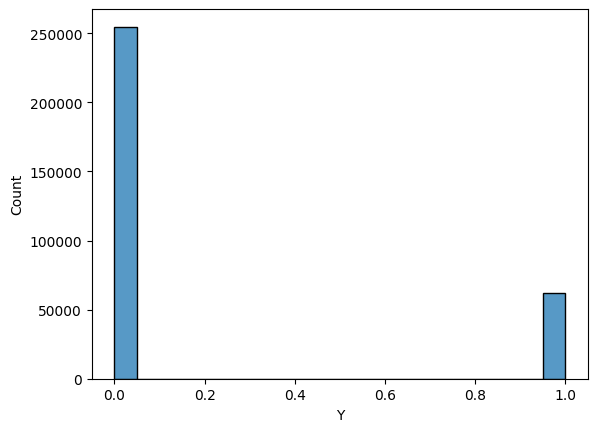

In [31]:
plot_value(df_raw,"Y")
print("Count Y distribution")
print(df_raw['Y'].value_counts())


30416 missing rows
Missing values:
ID         0
X1         0
X2         0
X3         0
X4         0
X5         0
X6         0
X7         0
X8         0
X9         0
X10        0
X11        0
X12        0
X13        0
X14        0
X15      230
X16        0
X17        0
X18        0
X19    30230
Y          0
dtype: int64


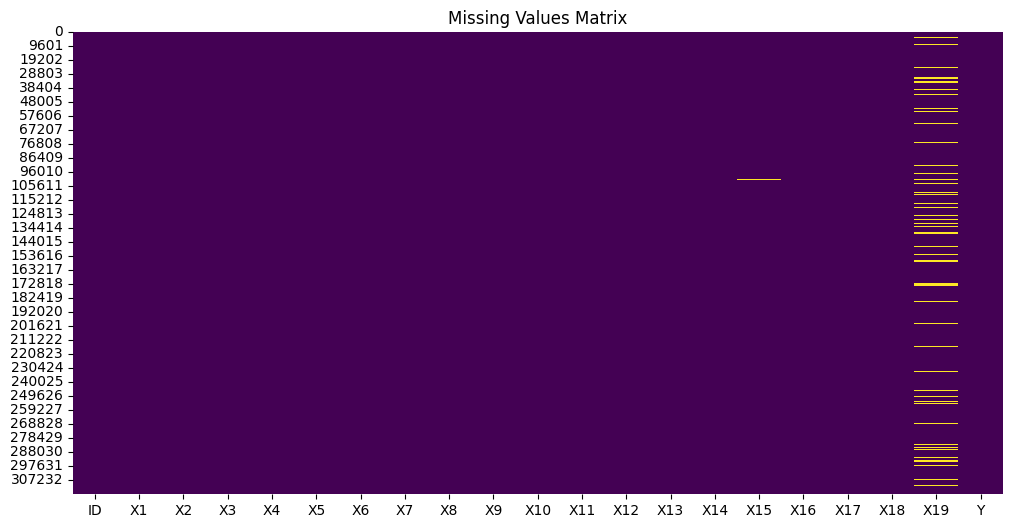

In [43]:
import missingno as msno
import matplotlib.pyplot as plt
# count missing rows

missing_rows = df_raw.isnull().any(axis=1).sum()
missing_count = df_raw.isnull().sum()
print(f"{missing_rows} missing rows")
print("Missing values:")
print(missing_count)
# Visualize the distribution of missing values using missingno matrix
plt.figure(figsize=(12, 6))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Matrix')
plt.show()



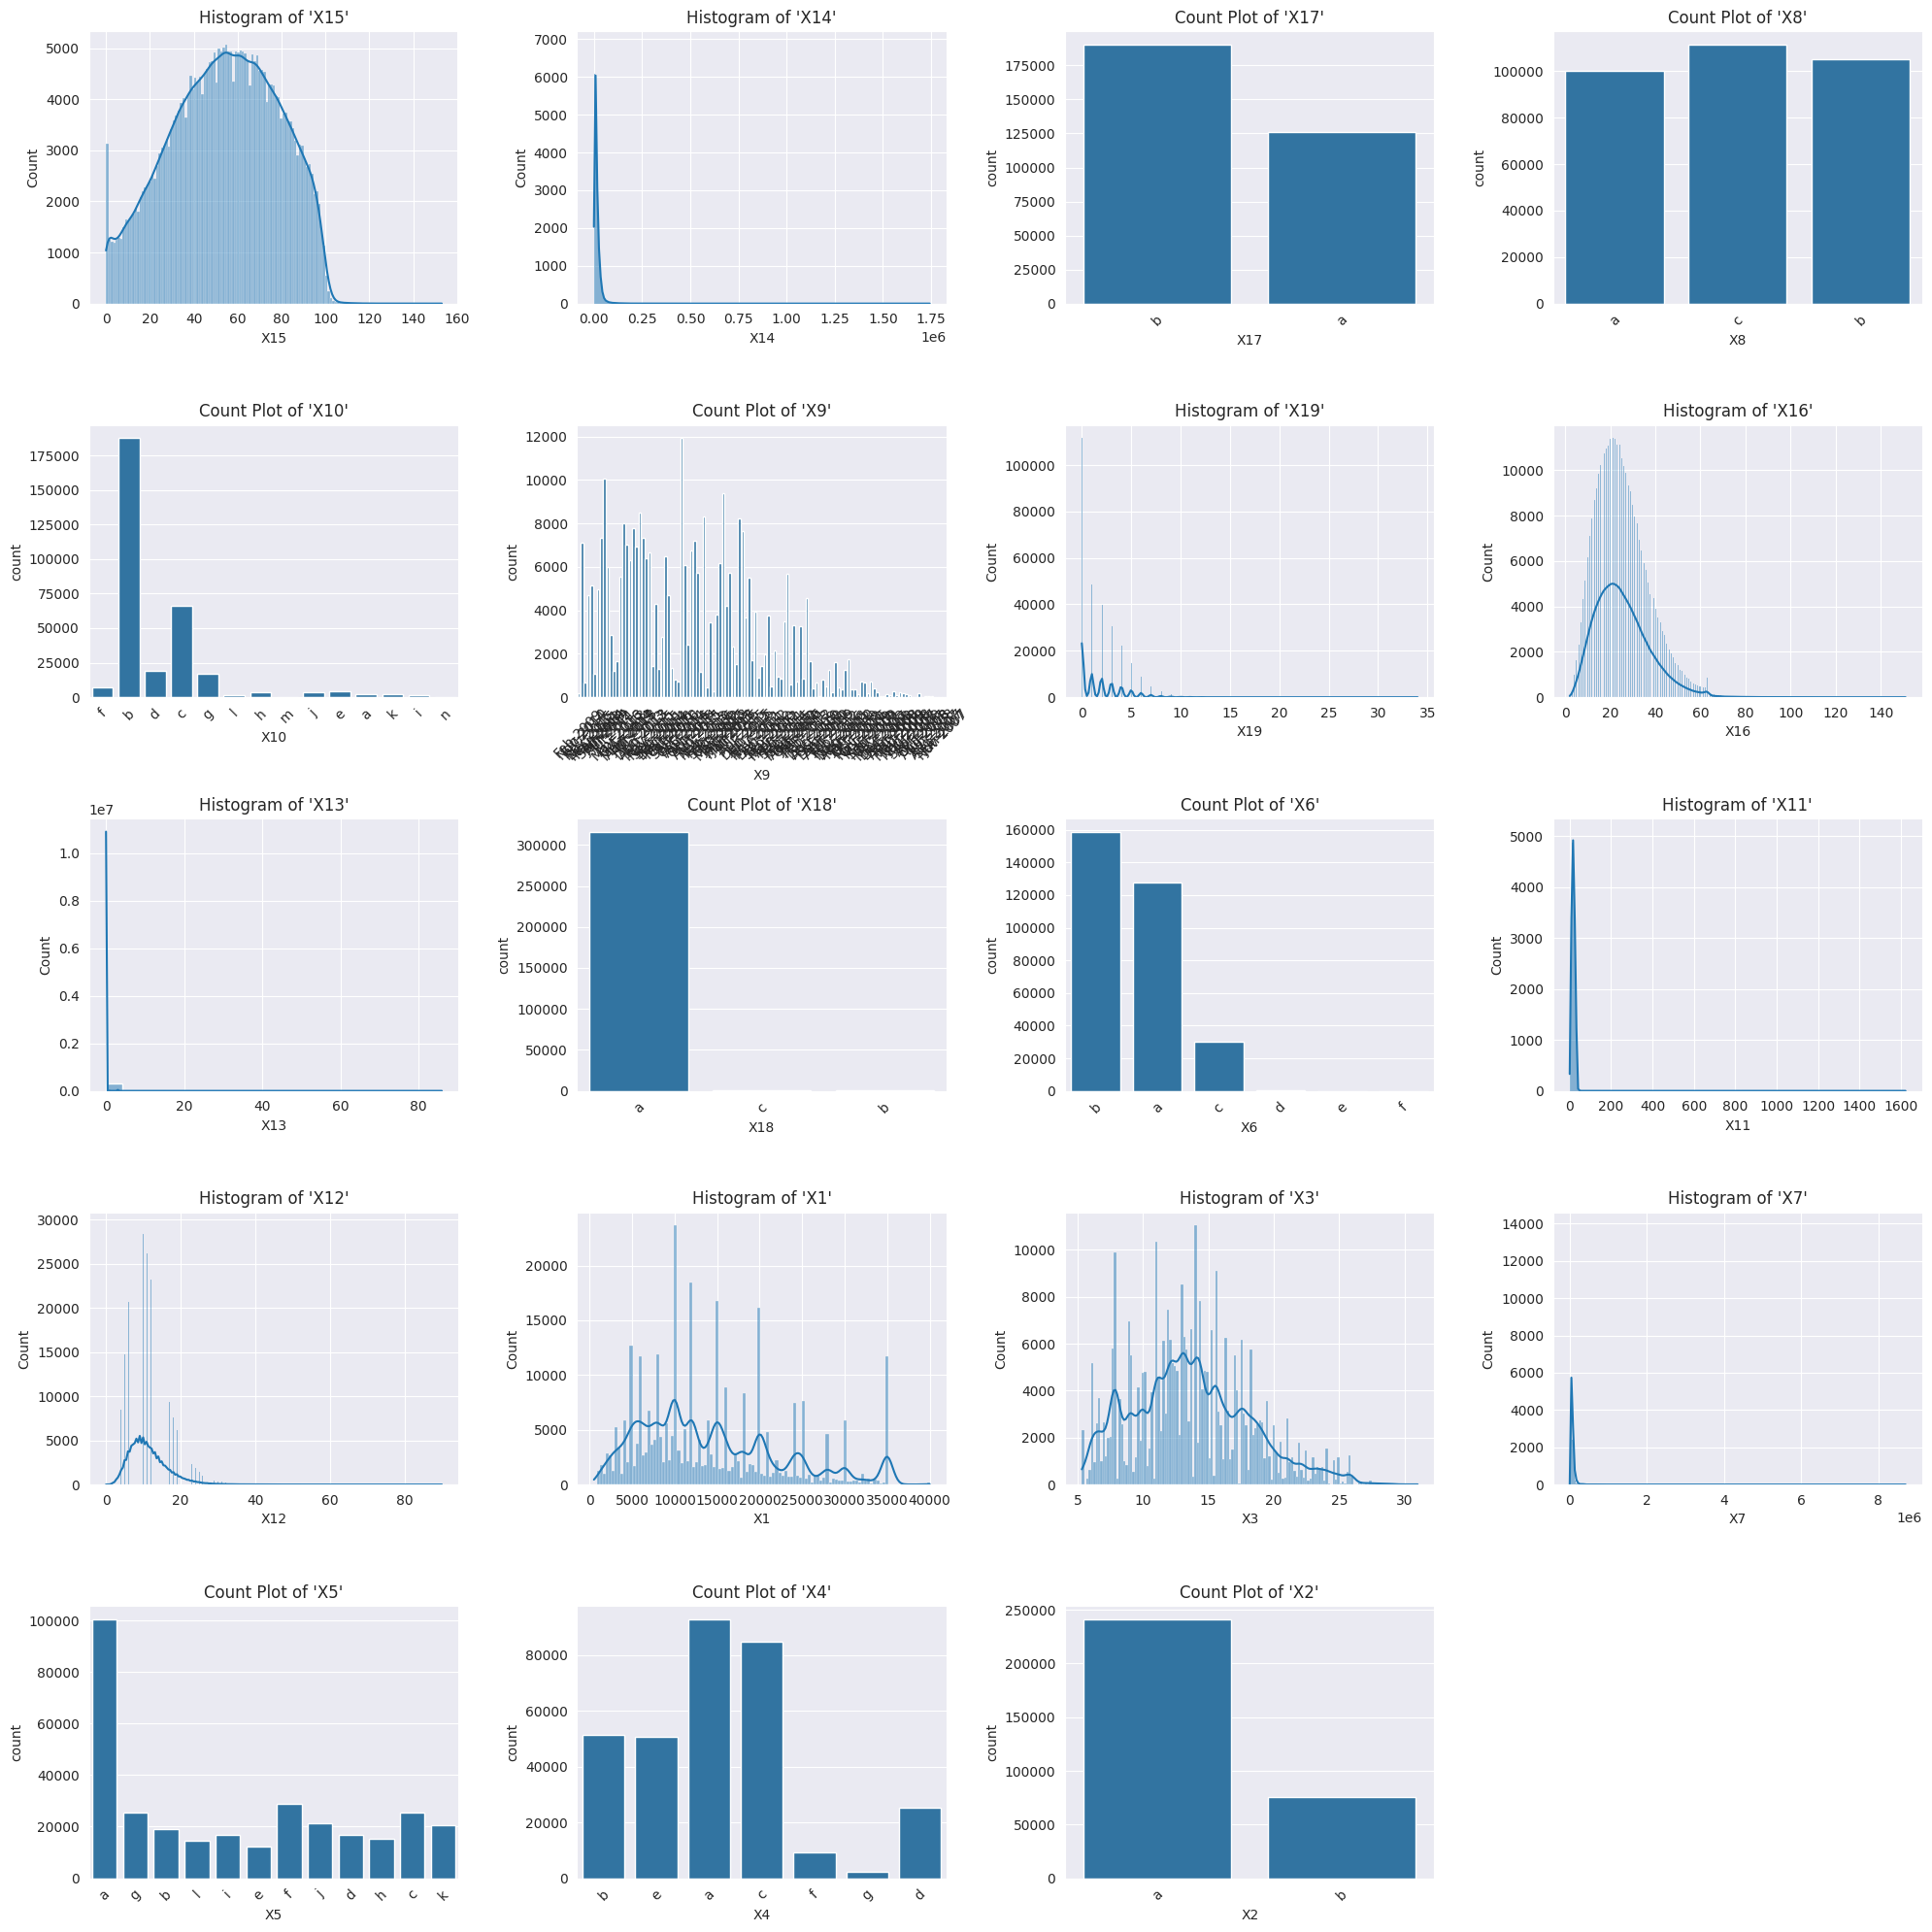

In [77]:
import matplotlib.pyplot as plt
import math
def plot_all_distributions(df,ignore: List[str]|None =None):
    if not ignore:
        ignore = []
    ignore = set(ignore)
    columns = list(set(df.columns) - ignore)
    n = len(columns)
    n_cols = 4  # number of plots per row
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()  # Flatten in case it's a 2D array of axes

    for i,col in enumerate(columns):
        ax = axes[i]
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.histplot(data=df, x=col, kde=True, ax=ax)

            ax.set_title(f"Histogram of '{col}'")
        else:
            sns.countplot(data=df, x=col, ax=ax)
            ax.set_title(f"Count Plot of '{col}'")
            ax.tick_params(axis='x', rotation=45)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])



    plt.tight_layout()
    plt.show()


plot_all_distributions(df_raw,["ID","Y"])

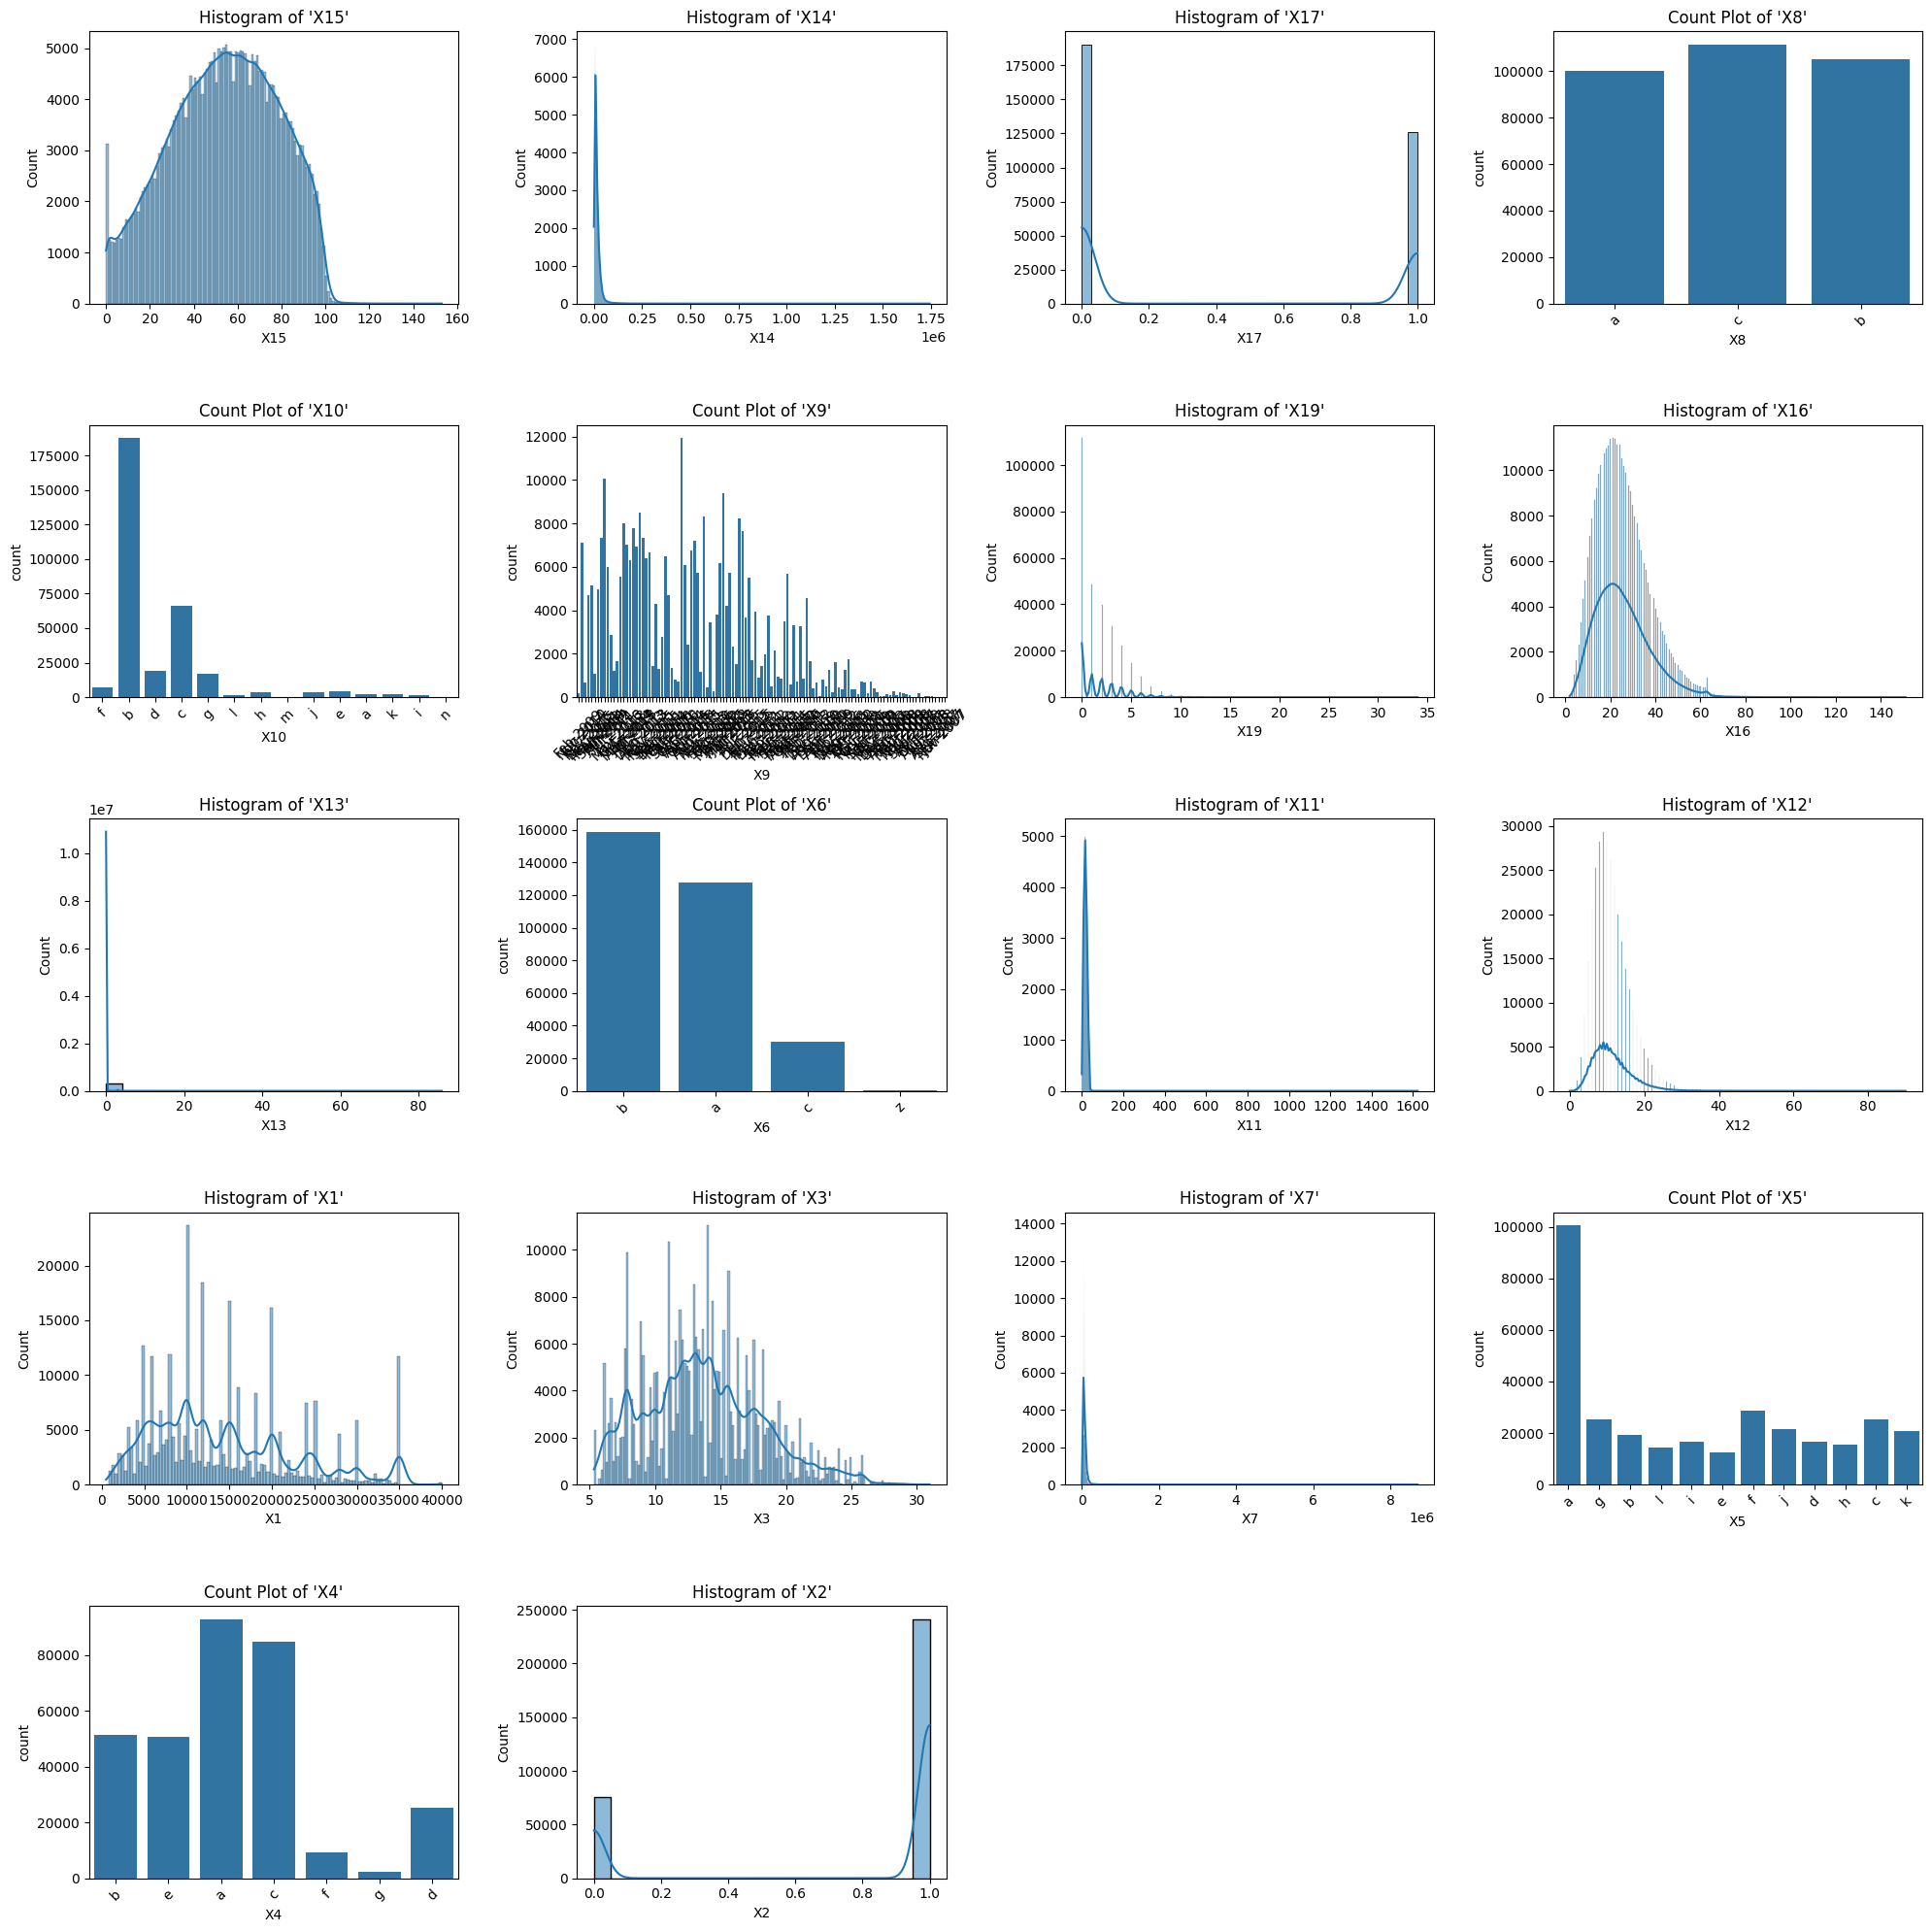

In [50]:
from sklearn.model_selection import OrdinalEncoder,

df_prefiltered = df_raw.copy()

#binarise
df_prefiltered["Y"].astype('bool')

binarise_list = ["X2","X17"]
for col in binarise_list:
    df_prefiltered[col] = df_prefiltered[col] == 'a'

#drop x18
df_prefiltered.drop(columns='X18',inplace=True)

#d,e,f -> z (unknown class)
X6_exclude = set(["d","e","f"])
df_prefiltered['X6'] = df_prefiltered['X6'].apply(lambda x: 'z' if x in X6_exclude else x)


plot_all_distributions(df_prefiltered,["ID","Y"])



KeyboardInterrupt: 

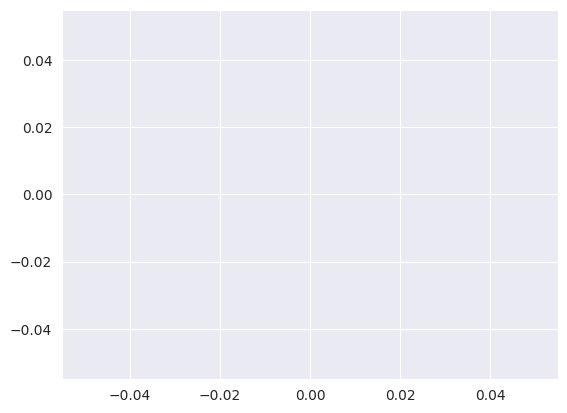

In [ ]:
from sklearn.model_selection import train_test_split


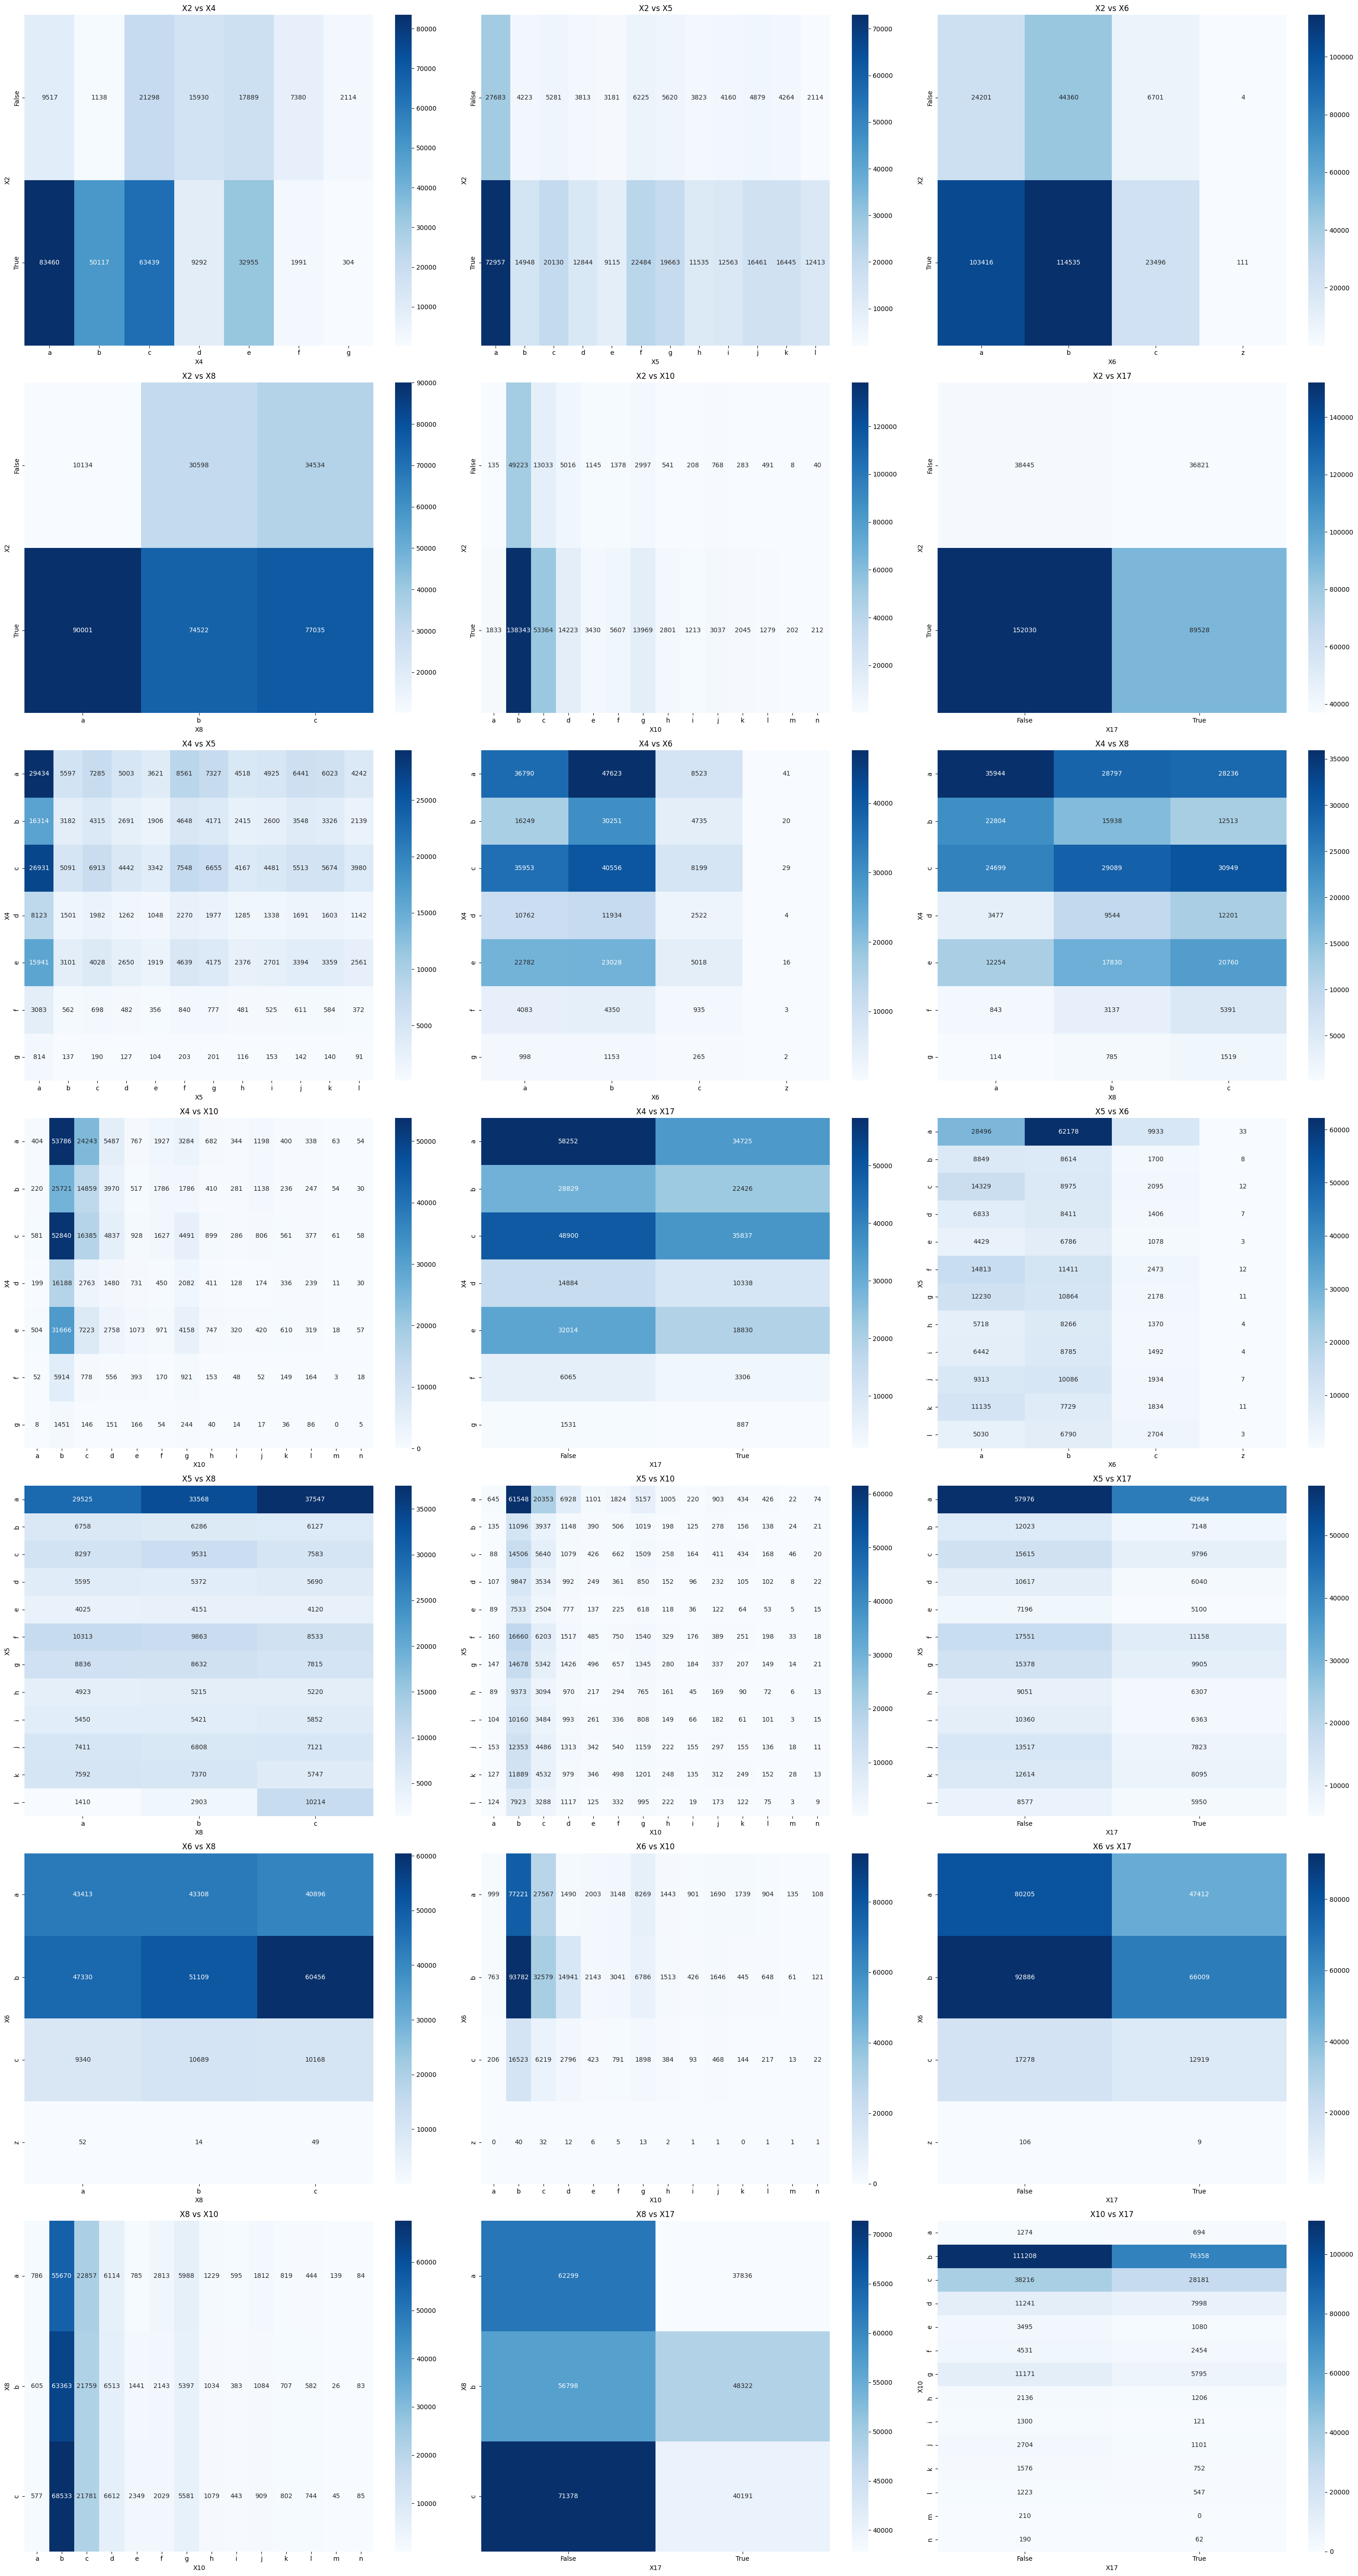

In [55]:
# examine some categorical data
from itertools import combinations
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from itertools import combinations
from typing import List

def plot_categorical_heatmaps(df: pd.DataFrame, cols: List[str]):
    SCALE=  2
    pairs = list(combinations(cols, 2))
    n = len(pairs)
    n_cols = 3  # plots per row
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5* SCALE * n_cols, 4*SCALE * n_rows))
    axes = axes.flatten()

    for i, (col1, col2) in enumerate(pairs):
        ax = axes[i]
        crosstab = pd.crosstab(df[col1], df[col2])
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f"{col1} vs {col2}")
        ax.set_xlabel(col2)
        ax.set_ylabel(col1)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_categorical_heatmaps(df_prefiltered,["X2","X4","X5","X6","X8","X10","X17"])


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, MinMaxScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,RobustScaler


from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, Binarizer
import pandas as pd

from sklearn.impute import SimpleImputer
import numpy as np


def clean_X6(X):
    X = X.copy()
    X6_include = set(["a", "b", "c"])
    X['X6'] = X['X6'].apply(lambda x: 'z' if x not in X6_include else x)
    return X

from datetime import datetime
def get_month(s):
    dt = datetime.strptime(s, "%b-%Y")
    return (dt.year - 1970) * 12 + (dt.month - 1)

def parse_date_X9(X):
    X = X.copy()
    X['X9'] = X['X9'].apply(lambda x: get_month(x))
    return X
from sklearn.pipeline import Pipeline
import numpy as np
# Define the column transformer (assuming OrdinalEncoder will be used on X6 later)

impute_and_scale_pipeline = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='mean')),
    ('scaler', RobustScaler())
])

# Create the full column transformer with proper handling of each column
ct = ColumnTransformer(
    transformers=[
        # Columns that need imputation and robust scaling
        ('impute_and_scale', impute_and_scale_pipeline, ['X15', 'X19']),

        # Binary values
        ('binarizer', Binarizer(), ['X13']),

        # Columns that only need robust scaling (no imputation needed)
        ('robust', RobustScaler(), ['X1', 'X3', 'X14']),

        # Min-max scaling for date column
        ('minmax', MinMaxScaler(), ['X9']),

        # Standard scaling
        ('standard', StandardScaler(), ["X7", "X11", "X12", "X16"]),

        # Ordinal encoding for categorical columns with order
        ('ordinal', OrdinalEncoder(), ['X17', "X2"]),

        ('drop_columns', 'drop', ["X18"]),

        # One-hot encoding for categorical columns with no inherent order
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['X4', 'X5', 'X6', 'X8', 'X10'])
    ],
    # Keep any columns not explicitly listed in transformers
    #remainder='drop'  # You can change to 'passthrough' if you want to keep other columns
)

# Combine everything into a pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('x6_cleaner', FunctionTransformer(clean_X6)),
    ('x9_parser', FunctionTransformer(parse_date_X9)),
    ('preprocess', ct)
])

In [3]:
from sklearn.model_selection import train_test_split
X = df_raw.drop(['Y','ID'], axis=1)
y = df_raw['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)



0 missing rows
Missing values:
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
43    0
44    0
45    0
46    0
47    0
48    0
49    0
50    0
51    0
52    0
dtype: int64


<Axes: >

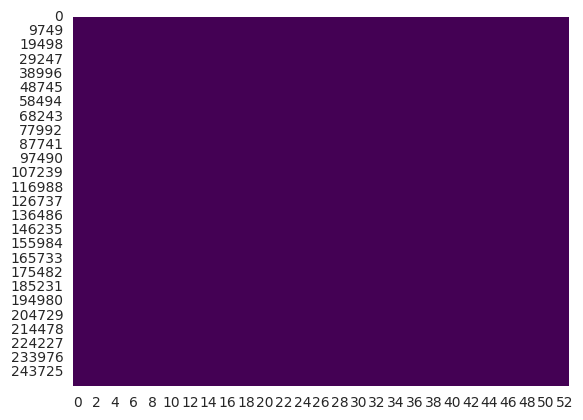

In [74]:
import seaborn as sns
traindf = pd.DataFrame(X_train)
missing_rows = traindf.isnull().any(axis=1).sum()
missing_count = traindf.isnull().sum()
print(f"{missing_rows} missing rows")
print("Missing values:")
print(missing_count)
# Visualize the distribution of missing values using missingno matrix

sns.heatmap(traindf.isnull(), cbar=False, cmap='viridis')





In [26]:
from xgboost import XGBClassifier  # or XGBRegressor if it's regression
from sklearn.metrics import f1_score
# Train XGBoost classifier
XGBmodel = XGBClassifier(use_label_encoder=False, eval_metric='logloss')  # disable warning
XGBmodel.fit(X_train, y_train)
# Predict and evaluate
y_pred_XGB = XGBmodel.predict(X_test)
f1 = f1_score(y_test, y_pred_XGB, average='weighted')  # or 'macro' depending on your case
print(f"F1 Score: {f1:.4f}")

/media/josh/LARGEHDD/Projects/InsightFactoryHackathon2025/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [03:24:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1 Score: 0.7563


In [24]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,ExtraTreesClassifier

rcf = RandomForestClassifier(random_state=0)
rcf.fit(X_train, y_train)
y_pred_rcf= rcf.predict(X_test)
print(f'The F1 Score is: {f1_score(y_test,y_pred_rcf,average='weighted')}')


The F1 Score is: 0.7469376877450358


In [32]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Define the model
class BinaryClassifier(nn.Module):
    def __init__(self, input_dim=52):
        super(BinaryClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 52),
            nn.ReLU(),
            nn.Linear(52, 200),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(200, 200),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(200, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Create model instance
model = BinaryClassifier(input_dim=53)

# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters())

# Training function
def train(X_train, y_train, X_test=None, y_test=None, epochs=5, batch_size=10):
    # Convert data to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

    # Create data loader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Training loop
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Print epoch statistics
        print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}')

        # Validation if test data provided
        if X_test is not None and y_test is not None:
            evaluate(X_test, y_test)

# Evaluation function
def evaluate(X_test, y_test):
    model.eval()
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

    with torch.no_grad():
        outputs = model(X_test_tensor)
        predicted = (outputs > 0.5).float()
        accuracy = (predicted == y_test_tensor).float().mean()

    print(f'Test Accuracy: {accuracy.item():.4f}')

train(X_train, y_train, X_test, y_test, epochs=20, batch_size=10)


Epoch 1/20, Loss: 0.4561
Test Accuracy: 0.8052
Epoch 2/20, Loss: 0.4526
Test Accuracy: 0.8062
Epoch 3/20, Loss: 0.4515
Test Accuracy: 0.8077
Epoch 4/20, Loss: 0.4512
Test Accuracy: 0.8080
Epoch 5/20, Loss: 0.4507
Test Accuracy: 0.8079
Epoch 6/20, Loss: 0.4506
Test Accuracy: 0.8059
Epoch 7/20, Loss: 0.4504
Test Accuracy: 0.8057
Epoch 8/20, Loss: 0.4501
Test Accuracy: 0.8056
Epoch 9/20, Loss: 0.4501
Test Accuracy: 0.8081
Epoch 10/20, Loss: 0.4505
Test Accuracy: 0.8064
Epoch 11/20, Loss: 0.4509
Test Accuracy: 0.8079
Epoch 12/20, Loss: 0.4496
Test Accuracy: 0.8074
Epoch 13/20, Loss: 0.4513
Test Accuracy: 0.8079
Epoch 14/20, Loss: 0.4499
Test Accuracy: 0.8066
Epoch 15/20, Loss: 0.4500
Test Accuracy: 0.8052
Epoch 16/20, Loss: 0.4528
Test Accuracy: 0.8064
Epoch 17/20, Loss: 0.4503
Test Accuracy: 0.8056
Epoch 18/20, Loss: 0.4492
Test Accuracy: 0.8057
Epoch 19/20, Loss: 0.4492
Test Accuracy: 0.8083
Epoch 20/20, Loss: 0.4504
Test Accuracy: 0.8067


In [33]:
from sklearn.metrics import f1_score
def evaluate(X_test, y_test):
    model.eval()
    X_test_tensor = torch.FloatTensor(X_test)

    with torch.no_grad():
        outputs = model(X_test_tensor)
        predicted = (outputs > 0.5).float().numpy().flatten()

    y_true = np.array(y_test).flatten()

    # Compute F1 score
    f1 = f1_score(y_true, predicted,average='weighted')

    print(f'F1 Score: {f1:.4f}')
evaluate(X_test, y_test)

F1 Score: 0.7267


In [34]:
NN = model
XGB = XGBmodel
RCF = rcf

def getmodelvalue():
    X_test_tensor = torch.FloatTensor(X_test)
    with torch.no_grad():
        outputs = NN(X_test_tensor)
        predicted = (outputs > 0.5).float().numpy().flatten()
        return predicted
NN_pred = getmodelvalue()
XGB_pred = y_pred_XGB
RCF_pred = y_pred_rcf

stacked_total = NN_pred + XGB_pred + RCF_pred

# Apply the threshold
result = (stacked_total >= 2).astype(int)
f1_score(y_test, result, average='weighted')



0.7420896684821243

In [110]:
testcsv = pd.read_csv("test.csv")
test_ID = testcsv['ID']
test_X = testcsv.drop(['ID'], axis=1)
test_X = pipeline.transform(test_X)
test_y = model.predict(test_X)

In [119]:
df_test_y = pd.Series(test_y)
df_results = pd.concat([test_ID, df_test_y], axis=1)
df_results.columns = ['ID', 'Y']

df_results.sort_values(by='ID', ascending=True, inplace=True)
df_results.head()
df_results.to_csv("testsubmission.csv", index=False)

In [90]:
df_transformed = pipeline.transform(df_raw)

In [91]:
df_transformed

array([[19.5       ,  1.81551952,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [75.4       ,  1.        ,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 2.        ,  1.81551952,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [55.3       ,  2.        ,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       [96.        ,  5.        ,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.6       ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(316824, 55))